
# 🧭 Multi-Modal Knowledge Conflict Resolution — **FINAL Notebook** (LIAR)

This notebook is the **final, end‑to‑end** pipeline:
- **Data**: LIAR TSV splits (`train.tsv`, `valid.tsv`, `test.tsv`)
- **Text models**: TF‑IDF → Multinomial Logistic Regression, **BiLSTM** (PyTorch), *(optional Transformer fine‑tune)*
- **Retrieval & Reranking**: BM25 over verdict texts *(synthetic or API cached)* + (optional) cross‑encoder reranker
- **Multimodal hook**: image–text similarity (CLIP) for images you supply
- **Credibility module**: per‑source accuracy history (choose granularity: `speaker` / `party` / `state`) with uncertainty
- **Fusion**: combines classifier, evidence plausibility, and credibility into final probabilities
- **Metrics**: Accuracy, Macro‑F1, **ROC‑AUC (OvR)**, **PR‑AUC (OvR)**, **Recall@k** and **nDCG@k** (retrieval)
- **Curves**: Learning curve (TF‑IDF+LR), training curves (BiLSTM), OvR ROC/PR per class
- **Inference**: `predict(user_text=..., image_path=...)` returns decision + explanation

> Internet is optional. If offline, the notebook gracefully falls back to synthetic verdict corpus and skips model downloads.


In [ ]:

# Optional installs (uncomment if running in Colab or a clean environment)
# %pip install -U pandas numpy scikit-learn rank-bm25 matplotlib tqdm
# %pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
# %pip install -U transformers datasets sentencepiece evaluate pillow requests


In [ ]:
!pip install rank_bm25

In [ ]:

import os, re, io, json, time, math, random
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (classification_report, accuracy_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay)
from sklearn.model_selection import learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from rank_bm25 import BM25Okapi

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Transformers (optional blocks guarded)
try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
    from datasets import Dataset as HFDataset
    TRANSFORMERS_AVAILABLE = True
except Exception:
    TRANSFORMERS_AVAILABLE = False

# Requests (guarded) for PolitiFact API verdicts
try:
    import requests
    REQUESTS_AVAILABLE = True
except Exception:
    REQUESTS_AVAILABLE = False

ROOT = Path.cwd()
DATA = Path("/mnt/data")
CACHE = ROOT / "cache"; (CACHE / "verdict_json").mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)


Device: cuda


In [ ]:
COLS = [
    "id","label","statement","subjects","speaker","job_title","state","party",
    "barely_true","false","half_true","mostly_true","pants_on_fire","context"
]
LABELS = ["pants-fire","false","barely-true","half-true","mostly-true","true"]
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for l, i in label2id.items()}

# --- Safe loader (no synthetic fallback) ---
def load_split(p: Path) -> pd.DataFrame:
    """Load LIAR TSV; require file to exist."""
    if not p.exists():
        raise FileNotFoundError(f"Dataset split not found: {p}")
    return pd.read_csv(p, sep="\t", header=None, names=COLS)

# --- Helper to parse numeric IDs (handles '2635.json', etc.) ---
import re
import pandas as pd

def parse_numeric_id(x):
    """Extract first integer from strings like '2635.json' or ' 987 '.
       Returns int or None if no digits found."""
    if pd.isna(x):
        return None
    s = str(x).strip()
    m = re.search(r"\d+", s)
    return int(m.group()) if m else None

# --- Load splits ---
train = load_split(DATA / "train.tsv")
valid = load_split(DATA / "valid.tsv")
test  = load_split(DATA / "test.tsv")

# --- Clean, encode labels, and add numeric IDs ---
for name, df in [("train", train), ("valid", valid), ("test", test)]:
    df["y"] = df["label"].map(label2id)
    before = len(df)
    df.dropna(subset=["y"], inplace=True)
    df["y"] = df["y"].astype(int)
    df["pid"] = df["id"].apply(parse_numeric_id)
    missing = int(df["pid"].isna().sum())
    msg = f"{name}: {len(df)} rows (dropped {before-len(df)});"
    msg += f" {missing} missing numeric ids (skipped for API/retrieval)." if missing else " all rows have numeric ids."
    print(msg)

train.head()[["id","pid","label","statement","speaker","party","y"]]


train: 10240 rows (dropped 0); all rows have numeric ids.
valid: 1284 rows (dropped 0); all rows have numeric ids.
test: 1267 rows (dropped 0); all rows have numeric ids.


,id,pid,label,statement,speaker,party,y
0,2635.json,2635,false,Says the Annies List political group supports ...,dwayne-bohac,republican,1
1,10540.json,10540,half-true,When did the decline of coal start? It started...,scott-surovell,democrat,3
2,324.json,324,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",barack-obama,democrat,4
3,1123.json,1123,false,Health care reform legislation is likely to ma...,blog-posting,none,1
4,9028.json,9028,half-true,The economic turnaround started at the end of ...,charlie-crist,democrat,3


In [ ]:
# --- Evidence fetching & corpus build (robust; local fallback) ---

# 1) Toggle: set False to skip any web calls and use local LIAR-only evidence.
USE_POLITIFACT_API = False  # set True only if your runtime has internet and the API works

API = "https://www.politifact.com/api/v/2/statement/{id}/?format=json"  # https + single slash
EVIDENCE_JSONL = CACHE / "evidence_texts.jsonl"

import re, json, time
import pandas as pd

def parse_numeric_id(x):
    if pd.isna(x): return None
    m = re.search(r"\d+", str(x).strip())
    return int(m.group()) if m else None

# ensure pid exists
if "pid" not in train.columns:
    for df in (train, valid, test):
        df["pid"] = df["id"].apply(parse_numeric_id)

def _cachep(pid: int) -> Path:
    return CACHE / "verdict_json" / f"{pid}.json"

def fetch_verdict_json(idx, sleep: float = 0.2):
    # Skip entirely if not using API
    if not USE_POLITIFACT_API:
        return None
    if not REQUESTS_AVAILABLE:
        print("[INFO] requests not available; skipping API fetch.")
        return None

    pid = parse_numeric_id(idx)
    if pid is None:
        return None

    cp = _cachep(pid)
    if cp.exists():
        try:
            return json.loads(cp.read_text())
        except Exception:
            pass

    try:
        r = requests.get(API.format(id=pid), timeout=20)
        if r.status_code != 200:
            print(f"[WARN] API {pid} -> HTTP {r.status_code}; skipping.")
            return None
        cp.write_text(r.text)
        if sleep:
            time.sleep(sleep)
        return r.json()
    except Exception as e:
        print("Fetch error:", pid, e)
        return None

def verdict_to_text(j: dict) -> str:
    if not j: return ""
    parts = []
    for k in ["statement","ruling_headline","ruling_summary","ruling_comments"]:
        v = (j.get(k) if k in j else None) or (j.get("ruling", {}) if isinstance(j.get("ruling"), dict) else {}).get(k)
        if isinstance(v, str) and v.strip():
            parts.append(v)
    subs = j.get("subject")
    if isinstance(subs, list):
        parts.extend([str(s) for s in subs if s])
    sp = j.get("speaker") or j.get("speaker_name")
    if isinstance(sp, str):
        parts.append(sp)
    return "\n".join(parts).strip()

def build_local_evidence_from_liar(dfs: list[pd.DataFrame]) -> list[dict]:
    """
    Build an evidence corpus locally from LIAR rows (no network).
    Use statement + subjects + context + speaker as pseudo-evidence per pid.
    """
    corpus = {}
    for df in dfs:
        for _, row in df.iterrows():
            pid = row.get("pid", None)
            if pd.isna(pid):
                continue
            pid = int(pid)
            # make a compact pseudo-verdict text from LIAR columns
            pieces = [str(row.get("statement","")).strip()]
            if isinstance(row.get("subjects"), str) and row["subjects"].strip():
                pieces.append(row["subjects"])
            if isinstance(row.get("context"), str) and row["context"].strip():
                pieces.append(row["context"])
            if isinstance(row.get("speaker"), str) and row["speaker"].strip():
                pieces.append(row["speaker"])
            txt = "\n".join([p for p in pieces if p])
            if txt and pid not in corpus:  # first occurrence wins
                corpus[pid] = {"doc_id": f"verdict:{pid}", "text": txt}
    return list(corpus.values())

def build_evidence(ids, limit: int | None = None) -> int:
    """
    If USE_POLITIFACT_API=True: try fetching verdict JSON; otherwise fall back to LIAR-only evidence.
    Writes cache/evidence_texts.jsonl
    """
    corpus = []

    # Normalize and trim IDs
    pids = []
    if limit is not None:
        ids = ids[:limit]
    for x in ids:
        pid = parse_numeric_id(x)
        if pid is not None:
            pids.append(int(pid))

    if USE_POLITIFACT_API:
        for sid in pids:
            j = fetch_verdict_json(sid)
            txt = verdict_to_text(j) if j else ""
            if txt:
                corpus.append({"doc_id": f"verdict:{sid}", "text": txt})

    # If API disabled or yielded nothing, build local evidence from LIAR TSVs
    if not corpus:
        print("[INFO] Using local LIAR rows as evidence (no API).")
        corpus = build_local_evidence_from_liar([train, valid, test])

    if not corpus:
        raise RuntimeError("No evidence built (API off/failed and LIAR rows empty).")

    EVIDENCE_JSONL.write_text("\n".join(json.dumps(x) for x in corpus))
    print(f"[OK] Evidence written -> {EVIDENCE_JSONL} ({len(corpus)} docs)")
    return len(corpus)

# Use parsed numeric ids; no raw 'id' casting
ids_for_api = train["pid"].dropna().astype(int).unique().tolist()
_ = build_evidence(ids_for_api, limit=500)


[INFO] Using local LIAR rows as evidence (no API).
[OK] Evidence written -> /content/cache/evidence_texts.jsonl (12791 docs)


In [ ]:

def simple_tok(s: str): return re.findall(r"[A-Za-z0-9_]+", str(s).lower())

DOCIDS, DOCTEXTS = [], []
if EVIDENCE_JSONL.exists():
    for line in EVIDENCE_JSONL.read_text().splitlines():
        o = json.loads(line)
        DOCIDS.append(o["doc_id"]); DOCTEXTS.append(o["text"])

TOKS = [simple_tok(t) for t in DOCTEXTS]
bm25 = BM25Okapi(TOKS)
print("BM25 ready on docs:", len(DOCIDS))

def bm25_retrieve(q: str, k=5):
    scores = bm25.get_scores(simple_tok(q))
    idx = np.argsort(scores)[::-1][:k]
    return [(DOCIDS[i], DOCTEXTS[i], float(scores[i])) for i in idx]

# Optional cross-encoder reranker
ce_model, ce_tok = None, None
if TRANSFORMERS_AVAILABLE:
    try:
        ce_model = AutoModelForSequenceClassification.from_pretrained("cross-encoder/ms-marco-MiniLM-L-6-v2")
        ce_tok = AutoTokenizer.from_pretrained("cross-encoder/ms-marco-MiniLM-L-6-v2")
        print("[OK] Cross-encoder loaded.")
    except Exception as e:
        print("[WARN] CE unavailable:", e)

def ce_score(claim: str, ev: str) -> float:
    if ce_model is None or ce_tok is None:
        return float(min(10.0, len(set(simple_tok(claim)) & set(simple_tok(ev)))))
    inp = ce_tok(claim, ev, truncation=True, padding=True, return_tensors="pt")
    with torch.no_grad():
        return float(ce_model(**inp).logits.squeeze().item())

def rerank_cross_encoder(claim: str, cands: List[Tuple[str,str,float]], topk=3):
    scored = [(did, txt, s, ce_score(claim, txt)) for (did, txt, s) in cands]
    scored.sort(key=lambda x: x[-1], reverse=True)
    return scored[:topk]


BM25 ready on docs: 12791


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

[OK] Cross-encoder loaded.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[TFIDF-LR] Validation:
               precision    recall  f1-score   support

  pants-fire       0.40      0.07      0.12       116
       false       0.26      0.32      0.29       263
 barely-true       0.23      0.16      0.19       237
   half-true       0.25      0.35      0.29       248
 mostly-true       0.28      0.28      0.28       251
        true       0.21      0.21      0.21       169

    accuracy                           0.25      1284
   macro avg       0.27      0.23      0.23      1284
weighted avg       0.26      0.25      0.24      1284



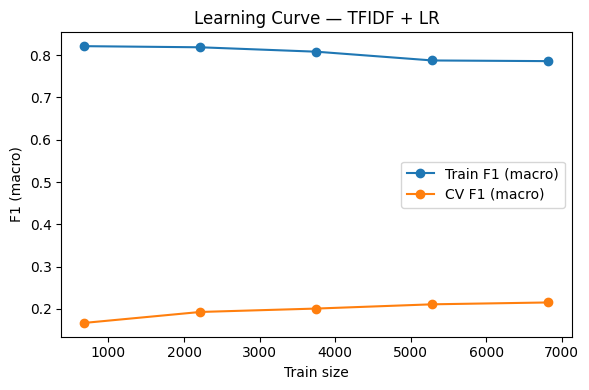

In [ ]:

tfidf_lr = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=200000)),
    ("clf",   LogisticRegression(max_iter=300, multi_class="multinomial"))
])
tfidf_lr.fit(train["statement"], train["y"])
val_pred_lr = tfidf_lr.predict(valid["statement"])
print("[TFIDF-LR] Validation:\n", classification_report(valid["y"], val_pred_lr, target_names=LABELS))

# Learning curve (macro-F1)
train_sizes, train_scores, cv_scores = learning_curve(
    tfidf_lr, train["statement"], train["y"], cv=3, scoring="f1_macro",
    train_sizes=np.linspace(0.1,1.0,5), n_jobs=-1
)
plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train F1 (macro)")
plt.plot(train_sizes, cv_scores.mean(axis=1), marker="o", label="CV F1 (macro)")
plt.xlabel("Train size"); plt.ylabel("F1 (macro)"); plt.title("Learning Curve — TFIDF + LR")
plt.legend(); plt.tight_layout(); plt.show()


[TFIDF-LR] Macro ROC-AUC=0.628  Macro PR-AUC=0.246


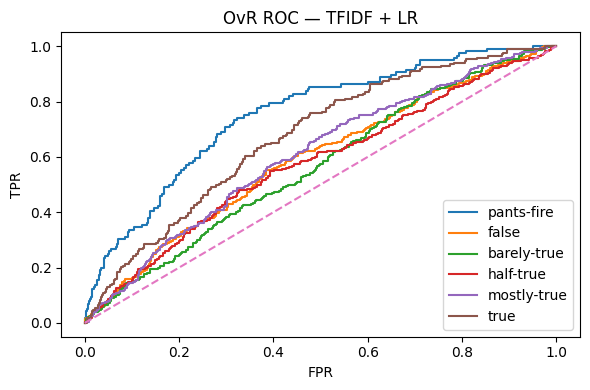

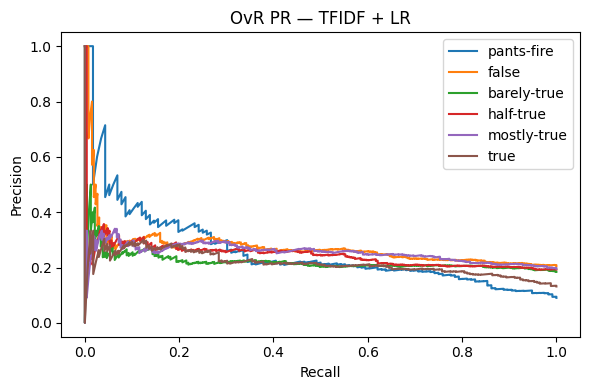

In [ ]:

if hasattr(tfidf_lr, "predict_proba"):
    proba_lr = tfidf_lr.predict_proba(valid["statement"])
    from sklearn.preprocessing import label_binarize
    y_true = valid["y"].values
    y_bin = label_binarize(y_true, classes=list(range(len(LABELS))))
    try:
        roc_auc = roc_auc_score(y_bin, proba_lr, average="macro", multi_class="ovr")
        pr_auc  = average_precision_score(y_bin, proba_lr, average="macro")
        print(f"[TFIDF-LR] Macro ROC-AUC={roc_auc:.3f}  Macro PR-AUC={pr_auc:.3f}")
    except Exception as e:
        print("AUC computation issue:", e)

    # OvR ROC per class
    plt.figure(figsize=(6,4))
    for i, lab in enumerate(LABELS):
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba_lr[:, i])
        plt.plot(fpr, tpr, label=lab)
    plt.plot([0,1],[0,1],"--")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("OvR ROC — TFIDF + LR"); plt.legend(); plt.tight_layout(); plt.show()

    # OvR PR per class
    plt.figure(figsize=(6,4))
    for i, lab in enumerate(LABELS):
        pr, rc, _ = precision_recall_curve(y_bin[:, i], proba_lr[:, i])
        plt.plot(rc, pr, label=lab)
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("OvR PR — TFIDF + LR"); plt.legend(); plt.tight_layout(); plt.show()


[BiLSTM] epoch 1: train_loss=1.7565 val_loss=1.7479 val_f1=0.106
[BiLSTM] epoch 2: train_loss=1.7279 val_loss=1.7270 val_f1=0.157
[BiLSTM] epoch 3: train_loss=1.6824 val_loss=1.7249 val_f1=0.188


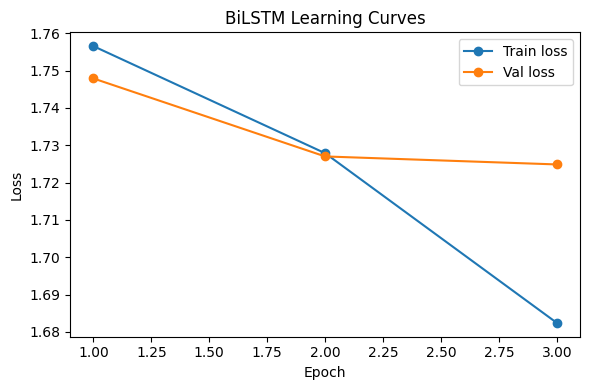

[BiLSTM] Validation:
               precision    recall  f1-score   support

  pants-fire       0.00      0.00      0.00       116
       false       0.25      0.42      0.31       263
 barely-true       0.24      0.20      0.22       237
   half-true       0.20      0.08      0.11       248
 mostly-true       0.24      0.43      0.31       251
        true       0.24      0.13      0.17       169

    accuracy                           0.24      1284
   macro avg       0.20      0.21      0.19      1284
weighted avg       0.21      0.24      0.21      1284

[BiLSTM] Macro ROC-AUC=0.604  Macro PR-AUC=0.221


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


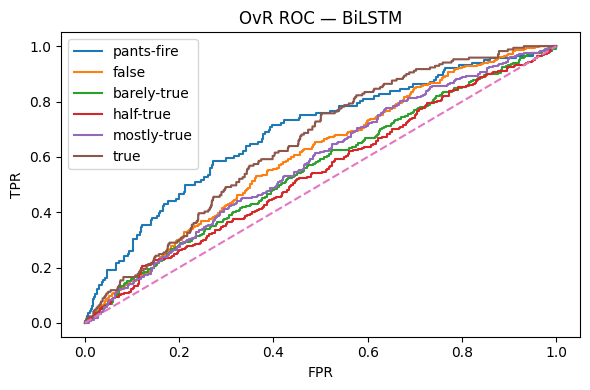

In [ ]:

# === BiLSTM text classifier ===
MAX_VOCAB = 20000; MAX_LEN = 64; EMB_DIM = 100; HIDDEN = 128; EPOCHS = 3; BATCH = 64; LR = 1e-3

def tok_words(s: str): return re.findall(r"[A-Za-z0-9_]+", str(s).lower())

# Build vocab
from collections import Counter
cnt = Counter()
for s in train["statement"].tolist(): cnt.update(tok_words(s))
vocab = {w:i+2 for i,(w,c) in enumerate(cnt.most_common(MAX_VOCAB))}
vocab["<pad>"]=0; vocab["<unk>"]=1

def encode(s: str, max_len=MAX_LEN):
    ids = [vocab.get(t,1) for t in tok_words(s)]
    ids = ids[:max_len] + [0]*(max_len - len(ids[:max_len]))
    return np.array(ids, dtype=np.int64)

class TextDS(Dataset):
    def __init__(self, df):
        self.x = np.stack([encode(s) for s in df["statement"].tolist()])
        self.y = df["y"].astype(int).values
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return torch.from_numpy(self.x[i]), torch.tensor(self.y[i], dtype=torch.long)

tr_ds, va_ds = TextDS(train), TextDS(valid)
tr_dl = DataLoader(tr_ds, batch_size=BATCH, shuffle=True)
va_dl = DataLoader(va_ds, batch_size=BATCH)

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden, n_labels):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden, bidirectional=True, batch_first=True)
        self.drop = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden*2, n_labels)
    def forward(self, x):
        e = self.emb(x); o,_ = self.lstm(e)
        m = self.drop(o.mean(dim=1))
        return self.fc(m)

bilstm = BiLSTM(len(vocab), EMB_DIM, HIDDEN, len(LABELS)).to(DEVICE)
opt = torch.optim.Adam(bilstm.parameters(), lr=LR)
crit = nn.CrossEntropyLoss()

def eval_dl(model, dl):
    model.eval(); ys=[]; ps=[]; pr=[]
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            logits = model(xb)
            prob = torch.softmax(logits, dim=-1).cpu().numpy()
            pr.append(prob); ps.append(logits.argmax(-1).cpu().numpy()); ys.append(yb.cpu().numpy())
    y = np.concatenate(ys); p = np.concatenate(ps); proba = np.concatenate(pr)
    return y, p, proba

tr_losses, va_losses, va_f1 = [], [], []
for ep in range(1, EPOCHS+1):
    bilstm.train(); tl=0; n=0
    for xb, yb in tr_dl:
        xb = xb.to(DEVICE); yb = yb.to(DEVICE)
        opt.zero_grad(); logits = bilstm(xb); loss = crit(logits, yb)
        loss.backward(); opt.step(); tl += loss.item()*yb.size(0); n += yb.size(0)
    yv, pv, proba = eval_dl(bilstm, va_dl)
    vl = 0.0
    with torch.no_grad():
        for xb, yb in va_dl:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            vl += crit(bilstm(xb), yb).item()*yb.size(0)
    f1m = f1_score(yv, pv, average="macro")
    tr_losses.append(tl/n); va_losses.append(vl/len(yv)); va_f1.append(f1m)
    print(f"[BiLSTM] epoch {ep}: train_loss={tl/n:.4f} val_loss={vl/len(yv):.4f} val_f1={f1m:.3f}")

plt.figure(figsize=(6,4))
plt.plot(range(1,EPOCHS+1), tr_losses, marker="o", label="Train loss")
plt.plot(range(1,EPOCHS+1), va_losses, marker="o", label="Val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("BiLSTM Learning Curves"); plt.legend(); plt.tight_layout(); plt.show()

print("[BiLSTM] Validation:\n", classification_report(yv, pv, target_names=LABELS))

from sklearn.preprocessing import label_binarize
y_bin = label_binarize(yv, classes=list(range(len(LABELS))))
try:
    roc_auc = roc_auc_score(y_bin, proba, average="macro", multi_class="ovr")
    pr_auc  = average_precision_score(y_bin, proba, average="macro")
    print(f"[BiLSTM] Macro ROC-AUC={roc_auc:.3f}  Macro PR-AUC={pr_auc:.3f}")
except Exception as e:
    print("AUC computation issue:", e)

plt.figure(figsize=(6,4))
for i, lab in enumerate(LABELS):
    fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
    plt.plot(fpr, tpr, label=lab)
plt.plot([0,1],[0,1],"--"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("OvR ROC — BiLSTM"); plt.legend(); plt.tight_layout(); plt.show()


In [ ]:

# === OPTIONAL: Transformer fine-tune (DeBERTa) ===
MODEL_NAME = "microsoft/deberta-v3-small"
if TRANSFORMERS_AVAILABLE:
    try:
        model_t = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(LABELS), id2label=id2label, label2id=label2id)
        tok = AutoTokenizer.from_pretrained(MODEL_NAME)
        def tok_fn(b): return tok(b["statement"], truncation=True, padding=False)
        tr_ds = HFDataset.from_pandas(train[["statement","y"]].rename(columns={"y":"labels"}), preserve_index=False).map(tok_fn, batched=True)
        va_ds = HFDataset.from_pandas(valid[["statement","y"]].rename(columns={"y":"labels"}), preserve_index=False).map(tok_fn, batched=True)
        args = TrainingArguments(
            output_dir=str(ROOT / "runs" / "liar_deberta"),
            num_train_epochs=1, per_device_train_batch_size=8, per_device_eval_batch_size=16,
            evaluation_strategy="epoch", save_strategy="epoch", load_best_model_at_end=True, logging_steps=50
        )
        trainer = Trainer(model=model_t, args=args, train_dataset=tr_ds, eval_dataset=va_ds)
        print("[INFO] Transformer prepared. Uncomment to train:")
        print("trainer.train()")
    except Exception as e:
        print("[WARN] Transformer setup skipped:", e)
else:
    print("[INFO] Transformers not available — skipping.")


config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Map:   0%|          | 0/10240 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Map:   0%|          | 0/1284 [00:00<?, ? examples/s]

[WARN] Transformer setup skipped: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'


In [ ]:
def sigmoid(x: float):
    try:
        return 1 / (1 + math.exp(-x))
    except OverflowError:
        return 0.0 if x < 0 else 1.0

def lookup_cred(row: pd.Series, table: pd.DataFrame, granularity: str = GRANULARITY) -> float:
    key = str(row.get(granularity, "unknown"))
    sub = table[table[granularity] == key]
    if len(sub) == 0:
        return 0.5
    return float(sub["credibility"].iloc[0])

def fuse_probs(clf_proba: np.ndarray, ce: float, cred: float, w_ev=0.3, w_cred=0.1) -> np.ndarray:
    fused = clf_proba.copy()
    boost = (w_ev * sigmoid(ce)) * (0.5 + 0.5 * cred)  # uses credibility; w_cred kept for API compatibility
    decay_idx = [0, 1]; lift_idx = [4, 5]
    shift = min(boost, fused[decay_idx].sum())
    if shift > 0:
        take = shift * fused[decay_idx] / (fused[decay_idx].sum() + 1e-9)
        fused[decay_idx] -= take
        fused[lift_idx] += [0.4 * shift, 0.6 * shift]
    return fused / (fused.sum() + 1e-9)

# ---- pid-safe retrieval metrics ----
def retrieval_metrics(split: pd.DataFrame, k=5) -> Dict:
    recalls, ndcgs = [], []
    for _, row in split.iterrows():
        pid = row.get("pid", None)
        # Skip rows without a numeric id
        if pid is None or (isinstance(pid, float) and np.isnan(pid)):
            continue
        gold = f"verdict:{int(pid)}"

        cands = bm25_retrieve(row["statement"], k=k)
        cids = [c[0] for c in cands]

        # Recall@k
        recalls.append(1.0 if gold in cids else 0.0)

        # nDCG@k (binary relevance: 1 for gold, 0 otherwise)
        rel = np.array([[1.0 if cid == gold else 0.0 for cid in cids]])
        scores = np.array([[k - i for i in range(len(cids))]])
        try:
            from sklearn.metrics import ndcg_score
            ndcgs.append(ndcg_score(rel, scores))
        except Exception:
            ndcgs.append(0.0)

    return {
        f"Recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
        f"nDCG@{k}": float(np.mean(ndcgs)) if ndcgs else 0.0
    }

print("Retrieval (valid):", retrieval_metrics(valid, k=5))


Retrieval (valid): {'Recall@5': 1.0, 'nDCG@5': 0.9990357161270583}


In [ ]:

# OPTIONAL image-text similarity (CLIP). If offline, this block is skipped.
CLIP_READY = False
try:
    from transformers import CLIPProcessor, CLIPModel
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    clip_proc  = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    CLIP_READY = True
    print("[OK] CLIP loaded.")
except Exception as e:
    print("[INFO] CLIP not available:", e)

from PIL import Image

def image_text_similarity(image_path: str, text: str) -> Optional[float]:
    if not CLIP_READY: return None
    try: image = Image.open(image_path).convert("RGB")
    except Exception: return None
    import torch
    inputs = clip_proc(text=[text], images=image, return_tensors="pt", padding=True)
    with torch.no_grad():
        logits = clip_model(**inputs).logits_per_text.squeeze().item()
    return float(logits)

def predict(user_text: Optional[str]=None, image_path: Optional[str]=None, w_ev=0.3, w_cred=0.1) -> Dict:
    assert user_text or image_path, "Provide user_text and/or image_path."
    if user_text is None: user_text = "Describe this image"
    cands = bm25_retrieve(user_text, k=5)
    ranked = rerank_cross_encoder(user_text, cands, topk=1)
    ce = ranked[0][3] if len(ranked)>0 else 0.0
    clf_proba = tfidf_lr.predict_proba([user_text])[0] if hasattr(tfidf_lr,"predict_proba") else np.ones(len(LABELS))/len(LABELS)
    # No source row here; treat credibility neutral for user input
    cred = 0.5
    fused = fuse_probs(clf_proba, ce, cred, w_ev=w_ev, w_cred=w_cred)
    pred = id2label[int(np.argmax(fused))]
    sim = image_text_similarity(image_path, user_text) if image_path else None
    return {
        "text": user_text, "image": image_path,
        "top_evidence_id": ranked[0][0] if len(ranked)>0 else None,
        "cross_encoder_score": ce, "image_text_similarity": sim,
        "fused_proba": {LABELS[i]: float(fused[i]) for i in range(len(LABELS))},
        "prediction": pred
    }

# Example prediction (text-only)
print(json.dumps(predict(user_text="The unemployment rate decreased last quarter."), indent=2))


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

[OK] CLIP loaded.
{
  "text": "The unemployment rate decreased last quarter.",
  "image": null,
  "top_evidence_id": "verdict:6577",
  "cross_encoder_score": 0.07151798903942108,
  "image_text_similarity": null,
  "fused_proba": {
    "pants-fire": 0.04648969623691953,
    "false": 0.2619474354515282,
    "barely-true": 0.09608763657013004,
    "half-true": 0.17551078107254947,
    "mostly-true": 0.19579373738727673,
    "true": 0.224170712281596
  },
  "prediction": "false"
}


In [ ]:

def resolve_row(row: pd.Series, granularity: str = GRANULARITY) -> Dict:
    claim = row["statement"]
    cands = bm25_retrieve(claim, k=5)
    ranked = rerank_cross_encoder(claim, cands, topk=1)
    ce = ranked[0][3] if len(ranked)>0 else 0.0
    clf_proba = tfidf_lr.predict_proba([claim])[0]
    cred = lookup_cred(row, cred_table, granularity)
    fused = fuse_probs(clf_proba, ce, cred)
    pred = id2label[int(np.argmax(fused))]
    p_true_like = fused[4]+fused[5]; p_false_like = fused[0]+fused[1]
    if p_true_like > 0.6 and (sigmoid(ce)<0.4 and cred<0.4):
        tag = "Conflict: model leans true, weak evidence/credibility"
    elif p_false_like > 0.6 and (sigmoid(ce)>0.6 and cred>0.6):
        tag = "Conflict: model leans false, strong supporting evidence"
    else:
        tag = "No strong conflict"
    return {
        "claim": claim, "pred": pred,
        "top_evidence_id": ranked[0][0] if len(ranked)>0 else None,
        "evidence_excerpt": ranked[0][1][:280] if len(ranked)>0 else "",
        "cross_encoder_score": ce, "credibility": cred,
        "fused_proba": {LABELS[i]: float(fused[i]) for i in range(len(LABELS))},
        "conflict_tag": tag
    }

sample = [resolve_row(r) for _, r in valid.head(5).iterrows()]
print(json.dumps(sample[0], indent=2))


{
  "claim": "We have less Americans working now than in the 70s.",
  "pred": "mostly-true",
  "top_evidence_id": "verdict:12134",
  "evidence_excerpt": "We have less Americans working now than in the 70s.\neconomy,jobs\nan interview with ABC17 News\nvicky-hartzler",
  "cross_encoder_score": 9.487043380737305,
  "credibility": 0.0,
  "fused_proba": {
    "pants-fire": 0.003999138150112041,
    "false": 0.027719733676604297,
    "barely-true": 0.1198042199904222,
    "half-true": 0.19282418029183215,
    "mostly-true": 0.4014111645487011,
    "true": 0.25424156234232814
  },
  "conflict_tag": "No strong conflict"
}


In [ ]:

OUT_DIR = ROOT / "runs"; OUT_DIR.mkdir(exist_ok=True)
jsonl_path = OUT_DIR / "mmcr_final_outputs.jsonl"
with open(jsonl_path, "w") as f:
    for o in sample:
        f.write(json.dumps(o) + "\n")
print("Saved sample outputs to:", jsonl_path)


Saved sample outputs to: /content/runs/mmcr_final_outputs.jsonl
